# FM Spectra Are Bessel Functions — from the DX7 to Sonar

Frequency modulation has a hidden Bessel skeleton. Phase-modulate a carrier with a single tone,

$$s(t)=\cos\!\big(\omega_c t + \beta\sin\omega_m t\big)
   =\sum_{n=-\infty}^{\infty} J_n(\beta)\,\cos\big((\omega_c+n\omega_m)t\big),$$

and each sideband at $\omega_c+n\omega_m$ comes out with amplitude **$J_n(\beta)$** — a Bessel
function of the modulation index $\beta$. This is what your *ear* hears in FM synthesis (Chowning's
DX7), what a *sonar* chirp puts in the water, and a *waterfall* spectrum makes visible. And the
**carrier vanishes at $\beta=2.405$** — the same $J_0$ zero that set the fibre-mode cutoff and the
hanging-chain fundamental. Engine: `griffiths.bessel`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from griffiths import bessel as bz

print("griffiths.bessel loaded")

griffiths.bessel loaded


## §1 The sidebands are $J_n(\beta)$ — measured vs predicted

Synthesize an FM tone, FFT it, and read the line amplitudes at $f_c+n f_m$. They land exactly on
$|J_n(\beta)|$.

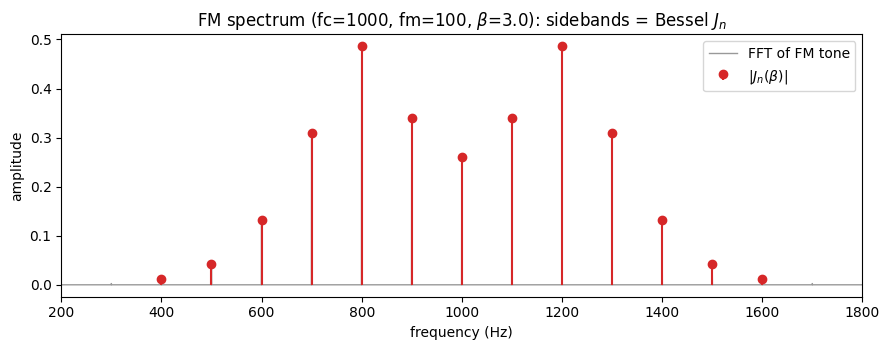

max |measured - |J_n||: 0.0


In [2]:
fs, dur = 8000, 2.0
t = np.arange(int(fs*dur)) / fs
fc, fm, beta = 1000.0, 100.0, 3.0
s = np.cos(2*np.pi*fc*t + beta*np.sin(2*np.pi*fm*t))
S = np.abs(np.fft.rfft(s)) / (len(s)/2)
freqs = np.fft.rfftfreq(len(s), 1/fs)

amps = bz.fm_sideband_amplitudes(beta, 6)
ns = np.arange(-6, 7)
Jn = np.array([amps[n] for n in ns])

plt.figure(figsize=(9, 3.6))
plt.plot(freqs, S, color="0.6", lw=1, label="FFT of FM tone")
plt.stem(fc + ns*fm, np.abs(Jn), linefmt="C3-", markerfmt="C3o", basefmt=" ", label="$|J_n(\\beta)|$")
plt.xlim(200, 1800); plt.xlabel("frequency (Hz)"); plt.ylabel("amplitude")
plt.title(f"FM spectrum (fc={fc:.0f}, fm={fm:.0f}, $\\beta$={beta}): sidebands = Bessel $J_n$")
plt.legend(); plt.tight_layout(); plt.show()
print("max |measured - |J_n||:",
      round(max(abs(S[np.argmin(np.abs(freqs-(fc+n*fm)))] - abs(amps[n])) for n in ns), 4))

## §2 The Bessel waterfall: spectrum vs modulation index

Sweep $\beta$ and stack the sideband powers $|J_n(\beta)|^2$. As $\beta$ grows, energy floods
outward into more sidebands (the bandwidth grows — Carson's rule $\approx 2(\beta+1)f_m$). The dark
curves threading the map are the **zeros of the $J_n$** — including the carrier ($n=0$) going dark at
$\beta=2.405$.

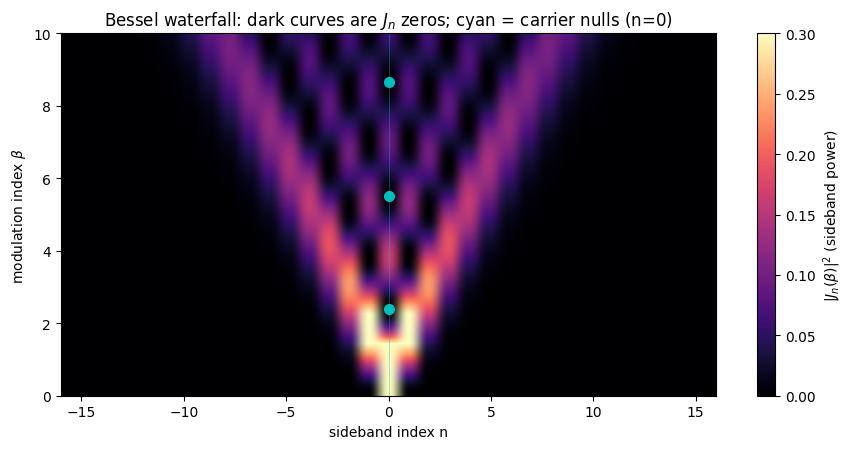

In [3]:
betas = np.linspace(0, 10, 300)
nmax = 16
power = np.array([[bz.fm_sideband_amplitudes(b, nmax)[n]**2 for n in range(-nmax, nmax+1)]
                  for b in betas])
plt.figure(figsize=(9, 4.6))
plt.imshow(power, aspect="auto", origin="lower", cmap="magma",
           extent=[-nmax, nmax, betas[0], betas[-1]], vmax=0.3)
plt.colorbar(label="$|J_n(\\beta)|^2$ (sideband power)")
for b in bz.carrier_null_indices(3):
    plt.plot(0, b, "co", ms=7)
plt.axvline(0, color="c", lw=0.5, alpha=0.5)
plt.xlabel("sideband index n"); plt.ylabel("modulation index $\\beta$")
plt.title("Bessel waterfall: dark curves are $J_n$ zeros; cyan = carrier nulls (n=0)")
plt.tight_layout(); plt.show()

## §3 The carrier null — the same 2.405

At $\beta=2.405$ the carrier line $J_0(\beta)$ hits its first zero: **all** the power has left the
carrier and gone into the sidebands. RF engineers use this to *calibrate* FM deviation (set $\beta$
until the carrier disappears on a spectrum analyzer). It is the identical $J_0$ zero from the optical
fibre and the hanging chain — one number, three fields.

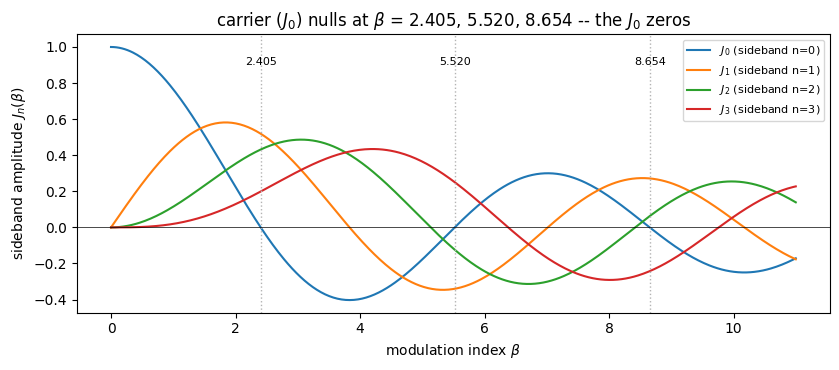

power check, sum J_n(beta)^2 = 1 for any beta: 1.0


In [4]:
bb = np.linspace(0, 11, 500)
plt.figure(figsize=(8.5, 3.8))
import mpmath as mp
for n in range(4):
    Jn = np.array([float(mp.besselj(n, b)) for b in bb])
    plt.plot(bb, Jn, label=f"$J_{n}$ (sideband n={n})")
nulls = bz.carrier_null_indices(3)
for b in nulls:
    plt.axvline(b, color="0.7", ls=":", lw=1)
    plt.annotate(f"{b:.3f}", (b, 0.9), fontsize=8, ha="center")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("modulation index $\\beta$"); plt.ylabel("sideband amplitude $J_n(\\beta)$")
plt.title("carrier ($J_0$) nulls at $\\beta$ = 2.405, 5.520, 8.654 -- the $J_0$ zeros")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()
print("power check, sum J_n(beta)^2 = 1 for any beta:",
      round(sum(v**2 for v in bz.fm_sideband_amplitudes(6.0, 50).values()), 5))

## §4 FM synthesis: what the ear hears

A small $\beta$ is a nearly pure tone; raise $\beta$ and the spectrum sprouts Bessel sidebands —
the timbre brightens from flute-like to brassy. This is exactly Chowning's FM synthesis (the Yamaha
DX7): a few oscillators and a modulation index buy a rich, evolving spectrum essentially for free.
Below, three timbres and their (Bessel) line spectra.

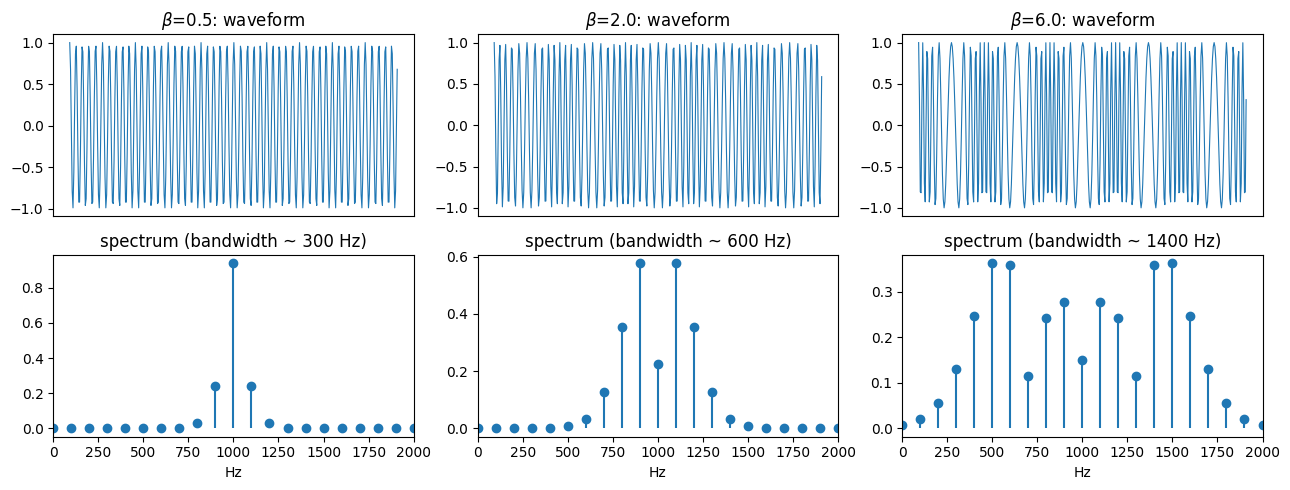

Carson bandwidth 2(beta+1)fm grows with beta -> brighter timbre, more Bessel sidebands.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 5))
for col, b in enumerate([0.5, 2.0, 6.0]):
    sig = np.cos(2*np.pi*fc*t + b*np.sin(2*np.pi*fm*t))
    axes[0, col].plot(t[:400], sig[:400], lw=0.8)
    axes[0, col].set_title(f"$\\beta$={b}: waveform"); axes[0, col].set_xticks([])
    ns = np.arange(-12, 13)
    amps = bz.fm_sideband_amplitudes(b, 12)
    axes[1, col].stem(fc + ns*fm, [abs(amps[n]) for n in ns], basefmt=" ")
    axes[1, col].set_title(f"spectrum (bandwidth ~ {2*(b+1)*fm:.0f} Hz)")
    axes[1, col].set_xlim(0, 2000); axes[1, col].set_xlabel("Hz")
plt.tight_layout(); plt.show()
print("Carson bandwidth 2(beta+1)fm grows with beta -> brighter timbre, more Bessel sidebands.")

## §5 The connections

- **FM = phase modulation = the repo's currency.** $s(t)=\cos(\omega_c t+\phi(t))$ with
  $\phi(t)=\beta\sin\omega_m t$ — the spectrum is set entirely by the *phase*. A linear chirp
  (instantaneous-frequency ramp) is FM with $\phi\propto t^2$, which is exactly the dispersive phase
  the TD-GS pipeline imposes; recovering $\phi$ from intensity is the whole project.
- **Bessel, one more time.** The fibre LP cutoff, the hanging chain, the helix diffraction, and now
  the FM carrier null are *the same* $J_0$ zeros (2.405, 5.520, ...). $J_n$ is the through-line of
  this entire summer of notebooks.
- **Real-time & underwater.** Sonar and radar use FM chirps; the receiver's matched filter and the
  Bessel sideband structure are two views of the same modulated phase. Power conservation
  $\sum_n J_n(\beta)^2=1$ guarantees FM only *moves* energy among sidebands, never creates it.
- **stochastic FM.** Replace the clean tone with band-limited noise and the discrete Bessel lines
  blur into a continuous spectrum — the deterministic skeleton (this notebook) underneath the random
  case.

Engine: `griffiths/bessel.py` gained `fm_sideband_amplitudes` and `carrier_null_indices`; verified in
`scripts/smoke_fm_bessel.py` (sidebands match $J_n$ to machine precision, $\sum J_n^2=1$).